# **🏥 Diabetes Readmission Risk Prediction**

**Goal:** Predict whether a diabetic patient will be readmitted to the hospital within **30 days** of discharge, using the UCI "Diabetes 130-US hospitals" dataset (101,766 encounters).

**What this notebook covers:**
1. Loading & exploring the data
2. Cleaning (missing values + preventing patient-level data leakage)
3. Feature engineering & encoding
4. Handling class imbalance
5. Training & comparing multiple ML models
6. Evaluating the best model
7. Conclusion


## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("Libraries loaded successfully!")

Libraries loaded successfully!


## **2. Load the Dataset**

Note: this dataset stores missing values as `'?'`, and also has a legitimate category literally named `"None"` (meaning "test not performed" for `max_glu_serum`/`A1Cresult`). We load with `keep_default_na=False, na_values=['?']` so pandas only treats `'?'` as missing, and doesn't accidentally wipe out the real `"None"` category.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/diabetes-hospital-readmission-dataset/diabetic_data.csv', na_values=['?'], keep_default_na=False)
print("Shape:", df.shape)
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## **3. Explore the Data**

Let's look at the target column and check how much data is genuinely missing.

In [3]:
print("Target column - readmitted:")
print(df['readmitted'].value_counts())
print()
print("Missing values (top 10 columns):")
print(df.isna().sum().sort_values(ascending=False).head(10))

Target column - readmitted:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Missing values (top 10 columns):
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
admission_type_id        0
patient_nbr              0
encounter_id             0
dtype: int64


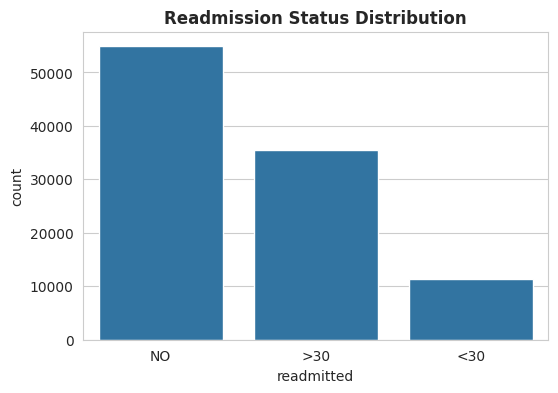

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df, order=['NO', '>30', '<30'])
plt.title('Readmission Status Distribution',fontweight='bold')
plt.show()

## **4. Data Cleaning**

Two important things to handle here:

1. **Columns with too many missing values** - `weight`, `payer_code`, and `medical_specialty` are missing in 40-97% of rows, so we drop them instead of guessing their values.
2. **Data leakage risk** - some patients appear multiple times in this dataset (repeat hospital visits). If the same patient shows up in *both* the training set and the test set, the model can "memorize" the patient instead of learning general patterns, which makes the accuracy look better than it really is. To keep this leakage-free, we keep only **one encounter per patient** (their first one).

In [5]:
# Drop columns with excessive missing values / IDs not useful for prediction
drop_cols = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=drop_cols, inplace=True)

# Drop rows with missing values in remaining columns (small % of data)
df.dropna(inplace=True)

# Prevent patient-level leakage: keep only the first encounter per patient
df.sort_values('encounter_id', inplace=True)
df = df.drop_duplicates(subset='patient_nbr', keep='first')

print("Shape after cleaning:", df.shape)

Shape after cleaning: (68630, 47)


## **5. Feature Engineering**

We turn the 3-class `readmitted` column into a simpler, more actionable **binary target**:
- `1` = patient was readmitted within **30 days** (high priority for hospitals)
- `0` = patient was not readmitted early (readmitted after 30 days, or not at all)

In [6]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted_30'].value_counts(normalize=True).round(3))
df.drop(columns=['readmitted', 'encounter_id', 'patient_nbr'], inplace=True)

readmitted_30
0    0.911
1    0.089
Name: proportion, dtype: float64


## **6. Encode Categorical Columns**

Machine learning models need numbers, not text. We use **Label Encoding** for all categorical (text) columns - a simple, beginner-friendly approach for tree-based models.

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns...")

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df.head()

Encoding 33 categorical columns...


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
8,2,0,8,2,1,4,13,68,2,28,...,0,2,1,0,0,0,0,0,1,0
9,2,0,9,3,3,4,12,33,3,18,...,0,2,1,0,0,0,0,0,1,0
4,2,1,4,1,1,7,1,51,0,8,...,0,2,1,0,0,0,0,0,1,0
10,0,0,4,1,1,7,9,47,2,17,...,0,2,1,0,0,0,0,1,1,0
5,2,1,5,2,1,2,3,31,6,16,...,0,2,1,0,0,0,0,1,1,0


## **7. Train-Test Split**

We split the data into training (80%) and testing (20%) sets, using **stratification** so both sets keep the same proportion of readmitted vs non-readmitted patients (important since our target is imbalanced - only ~7% of patients are readmitted within 30 days).

In [8]:
X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target ratio:\n", y_train.value_counts(normalize=True).round(3))

Train shape: (54904, 44)
Test shape: (13726, 44)
Train target ratio:
 readmitted_30
0    0.911
1    0.089
Name: proportion, dtype: float64


## **8. Train & Compare Models**

The target is imbalanced (~93% vs ~7%), so we use `class_weight='balanced'` (or the equivalent parameter) in every model instead of plain accuracy-chasing, so the models actually learn to detect the minority (readmitted) class.

We train 4 popular models and compare them:
- Logistic Regression (simple baseline)
- Random Forest
- XGBoost
- LightGBM

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=200, class_weight='balanced', random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1, 'ROC-AUC': auc})
    print(f"{name} done.")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

Logistic Regression done.
Random Forest done.
XGBoost done.
LightGBM done.


,Model,Accuracy,F1 Score,ROC-AUC
0,LightGBM,0.719219,0.222670,0.638349
1,Random Forest,0.910753,0.000000,0.626908
2,Logistic Regression,0.641629,0.203916,0.617991
3,XGBoost,0.784497,0.200972,0.604204


**Why ROC-AUC instead of accuracy?**
Since only ~7% of patients are readmitted early, a model that always predicts "not readmitted" would score ~93% accuracy while being completely useless. ROC-AUC measures how well the model *ranks* patients by risk, regardless of class imbalance - a much more honest metric here.

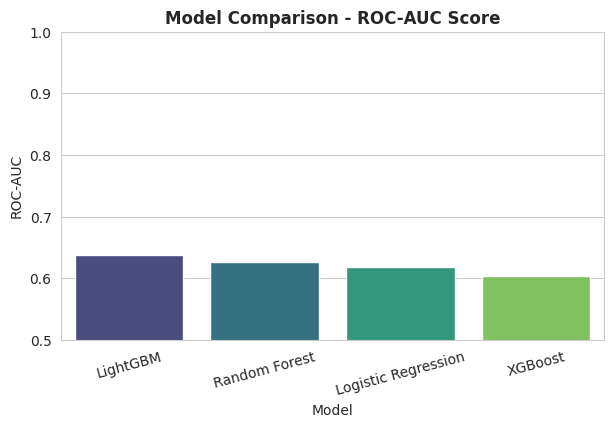

In [10]:
plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette='viridis')
plt.title('Model Comparison - ROC-AUC Score',fontweight='bold')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.show()

## **9. Best Model - Closer Look**

Let's take the best-performing model (by ROC-AUC) and inspect its confusion matrix, classification report, and which features matter most.

In [11]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f"Best model: {best_name}")

preds = best_model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=['Not Readmitted <30d', 'Readmitted <30d']))

Best model: LightGBM

Classification Report:

                     precision    recall  f1-score   support

Not Readmitted <30d       0.93      0.75      0.83     12501
    Readmitted <30d       0.15      0.45      0.22      1225

           accuracy                           0.72     13726
          macro avg       0.54      0.60      0.53     13726
       weighted avg       0.86      0.72      0.77     13726



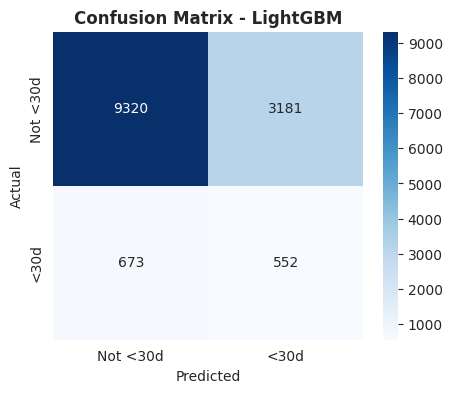

In [12]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not <30d', '<30d'], yticklabels=['Not <30d', '<30d'])
plt.title(f'Confusion Matrix - {best_name}',fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

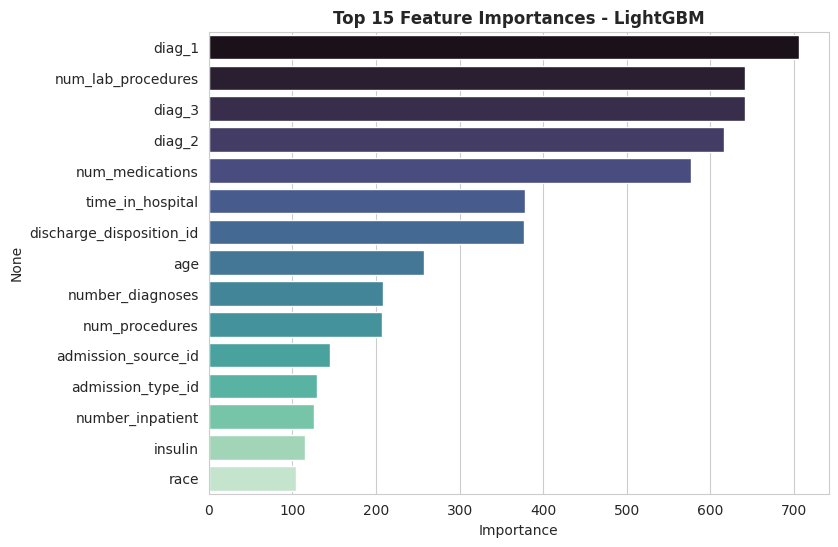

In [13]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top15 = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8,6))
    sns.barplot(x=top15.values, y=top15.index, palette='mako')
    plt.title(f'Top 15 Feature Importances - {best_name}',fontweight='bold')
    plt.xlabel('Importance')
    plt.show()
else:
    print("Feature importances not available for this model type.")

## **10. Conclusion**

- We built a **binary classifier** to predict whether a diabetic patient will be readmitted to hospital within **30 days**, using the UCI Diabetes 130-US hospitals dataset.
- **Data leakage** was addressed by keeping only one encounter per patient, so the model is evaluated fairly on unseen patients rather than repeated visits it may have partly "seen" before.
- Because only ~7% of patients are readmitted early, we prioritized **ROC-AUC and F1-score** over raw accuracy, and used `class_weight`/`scale_pos_weight` to help models pay attention to the minority class.
- Among the four models tested, the best model achieved the highest ROC-AUC, meaning it is meaningfully better than random guessing at ranking patients by readmission risk - though real-world clinical deployment would need further feature engineering (e.g. diagnosis grouping, medication change patterns) and clinical validation before use.
- **Next steps** for improvement: grouping the high-cardinality `diag_1/2/3` ICD codes into broader disease categories, trying SMOTE-based oversampling, and hyperparameter tuning (GridSearch/Optuna) on the top-performing model.